In [613]:
#Install libraries ONLY RUN THIS IF YOU DO NOT HAVE IT
!pip install pandas numpy vaderSentiment textblob matplotlib seaborn bs4 contractions transformers torch huggingface_hub[hf_xet] hf_xet datasets

In [614]:
#Necessary Libraries for this File
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns
import statistics
import datetime
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from bs4 import BeautifulSoup
import contractions
import random
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from spacy.lang.en.stop_words import STOP_WORDS
import spacy
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob
import time

# STEP 1:

## Dataset Chosen: Airline Reviews
## URL for Dataset: https://www.kaggle.com/datasets/chaudharyanshul/airline-reviews
## Why this dataset: This is a real world problem that companies are dealing with all the time. It is important to be able to perform a text analysis on the reviews that they are receiving. In a customer service industry it is important to take every single piece of information to improve the customerservice you are providing. Even if it is qualitative data, it is important to understand everything that people write about the company. This information being public can affect the company's bottom line and the way that other people percieve the airline (in this case, British Airways).

In [616]:
#Import the Dataset so that we can begin to explore it. Edit the path depending on the download
review_df=pd.read_csv(r"C:\Users\ysass\OneDrive\Desktop\Grad School Files\BSAN 6200 Text Mining and Social Media Analytics\text-analytics-spring-2026\assignment1\data\raw\BA_AirlineReviews.csv",header=0, index_col='Id', encoding="utf-8")

In [617]:
#STEP 2: Exploring the Dataset


review_df
#2.1.1 Metadata Description: Answer the Following Questions
#Columns and what the datatypes should be?
#Id- the ID of the row in the dataset(Should be a string because
#OverallRating- The overall rating given to the British Airways by the customer. (This should be an float because it can have decimal value)
#ReviewHeader- The header or title of the customer's review (String because it is a title with text)
#Name- Name of the customer that is giving the review to British Airways (Should be a string because it is a value)
#Datetime- The date the person wrote the review. (As it currently sits it is a string, but once we remove the th or rd from the string, it should be a datetime value)
#VerifiedReview-Indicates whether the review is verified or not (Boolean because it is either verified or not)
#ReviewBody- The full review written out by the customer (String because it is a full body of text)
#TypeOfTraveller- The type of traveller (i.e. Business, Leisure, etc.). (String because it is comprised of text)
#SeatType- Class of the traveler i.e. Economy, Business, etc. (String because it describes the class in text)
#Route-Flight Route taken by the customer (String because it is comprised of text)
#DateFlown- The date the person flew. (As it currently sits it is a string, but once we remove the th or rd from the string, it should be a datetime value)
#SeatComfort- Rating the comfort of the seat. (This should be an float because it can have decimal value)
#CabinStaffService- Rating of the flight attendants and cabin service staff. (This should be an float because it can have decimal value)
#GroundService- Rating for the ground service (i.e. Check-in, service desk, etc.). (This should be an float because it can have decimal value)
#ValueForMoney- Rating for the value of money. (This should be an float because it can have decimal value)
#Recommended- Whether the customer recommends British Airways. (It is a Boolean because they either recommend the airline or do not)
#Aircraft- The type of aircraft used for the flight. (String because it is something that we can't change and includes text)
#Food&Beverages- Rating for food and beverages. (This should be an float because it can have decimal value)
#InflightEntertainment- Rating for inflight entertainment. (This should be an float because it can have decimal value)
#Wifi&Connectivity- Rating for onboard wifi and connectivity. (This should be an float because it can have decimal value)


,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,DateFlown,SeatComfort,CabinStaffService,GroundService,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity
Id,,,,,,,,,,,,,,,,,,,
0,1.0,"""Service level far worse then Ryanair""",L Keele,19th November 2023,True,4 Hours before takeoff we received a Mail stat...,Couple Leisure,Economy Class,London to Stuttgart,Nov-23,1.0,1.0,1.0,1.0,no,NaN,NaN,NaN,NaN
1,3.0,"""do not upgrade members based on status""",Austin Jones,19th November 2023,True,I recently had a delay on British Airways from...,Business,Economy Class,Brussels to London,Nov-23,2.0,3.0,1.0,2.0,no,A320,1.0,2.0,2.0
2,8.0,"""Flight was smooth and quick""",M A Collie,16th November 2023,False,"Boarded on time, but it took ages to get to th...",Couple Leisure,Business Class,London Heathrow to Dublin,Nov-23,3.0,3.0,4.0,3.0,yes,A320,4.0,NaN,NaN
3,1.0,"""Absolutely hopeless airline""",Nigel Dean,16th November 2023,True,"5 days before the flight, we were advised by B...",Couple Leisure,Economy Class,London to Dublin,Dec-22,3.0,3.0,1.0,1.0,no,NaN,NaN,NaN,NaN
4,1.0,"""Customer Service is non existent""",Gaylynne Simpson,14th November 2023,False,"We traveled to Lisbon for our dream vacation, ...",Couple Leisure,Economy Class,London to Lisbon,Nov-23,1.0,1.0,1.0,1.0,no,NaN,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3696,1.0,British Airways customer review,J Robertson,29th August 2012,False,This was a bmi Regional operated flight on a R...,NaN,Economy Class,NaN,NaN,3.0,1.0,NaN,3.0,no,NaN,2.0,NaN,NaN
3697,9.0,British Airways customer review,Nick Berry,28th August 2012,False,LHR to HAM. Purser addresses all club passenge...,NaN,Business Class,NaN,NaN,4.0,5.0,NaN,3.0,yes,NaN,4.0,NaN,NaN
3698,5.0,British Airways customer review,Avril Barclay,12th October 2011,False,My son who had worked for British Airways urge...,NaN,Economy Class,NaN,NaN,NaN,NaN,NaN,4.0,yes,NaN,NaN,NaN,NaN


In [618]:
#2.1.2: What are the datatypes of the columns currently?
#Code identifies the data types for each column in the review_df
review_df.dtypes

OverallRating            float64
ReviewHeader              object
Name                      object
Datetime                  object
VerifiedReview              bool
ReviewBody                object
TypeOfTraveller           object
SeatType                  object
Route                     object
DateFlown                 object
SeatComfort              float64
CabinStaffService        float64
GroundService            float64
ValueForMoney            float64
Recommended               object
Aircraft                  object
Food&Beverages           float64
InflightEntertainment    float64
Wifi&Connectivity        float64
dtype: object

In [619]:
#2.1.3: How many rows are there?

#Code sets the number of rows (length) within the dataframe to a variable
num_rows=len(review_df)

#Print out the number of rows
print(f"There are {num_rows} rows in this dataset")

There are 3701 rows in this dataset


In [620]:
#2.1.4: Number of Missing Values per column

#Counts the number of NA values and sums it up to show how many missing values were in each column
review_df.isna().sum()

OverallRating               5
ReviewHeader                0
Name                        0
Datetime                    0
VerifiedReview              0
ReviewBody                  0
TypeOfTraveller           771
SeatType                    2
Route                     775
DateFlown                 778
SeatComfort               116
CabinStaffService         127
GroundService             846
ValueForMoney               1
Recommended                 0
Aircraft                 1779
Food&Beverages            386
InflightEntertainment    1150
Wifi&Connectivity        3092
dtype: int64

In [621]:
#2.1.5: Which Column Contains the Main Text?

#Shows the values of the review body
review_df["ReviewBody"]


Id
0       4 Hours before takeoff we received a Mail stat...
1       I recently had a delay on British Airways from...
2       Boarded on time, but it took ages to get to th...
3       5 days before the flight, we were advised by B...
4       We traveled to Lisbon for our dream vacation, ...
                              ...                        
3696    This was a bmi Regional operated flight on a R...
3697    LHR to HAM. Purser addresses all club passenge...
3698    My son who had worked for British Airways urge...
3699    London City-New York JFK via Shannon on A318 b...
3700    SIN-LHR BA12 B747-436 First Class. Old aircraf...
Name: ReviewBody, Length: 3701, dtype: object

In [622]:
#2.2.1: Descriptive Statistics

#Calculates descriptive statistics for the reviews and prints it
print("Minimum Text Length in Characters: "+ str(min(review_df["ReviewBody"].str.len()))+ " characters")
print("Maximum Text Length in Characters: "+ str(max(review_df["ReviewBody"].str.len()))+ " characters")
print("Average Text Length in Characters: "+ str(np.mean(review_df["ReviewBody"].str.len()))+ " characters")
print("Median Text Length in Characters: "+ str(statistics.median(review_df["ReviewBody"].str.len()))+ " characters")

Minimum Text Length in Characters: 83 characters
Maximum Text Length in Characters: 3529 characters
Average Text Length in Characters: 881.2842475006755 characters
Median Text Length in Characters: 736 characters


In [623]:
#2.2.2 Show 5-10 Random Samples

#Picks 10 random numbers and stores the list in a variable
number = random.sample(range(1, num_rows), 10)
print(number)

#Runs a loop through the random numbers and prints the corresponding review
for i in range(0, len(number)):
    print(f"Sample {i+1}, Review {number[i]}: {review_df['ReviewBody'][i]}")

[2603, 2309, 2394, 3215, 1446, 2147, 841, 3047, 3169, 895]
Sample 1, Review 2603: 4 Hours before takeoff we received a Mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. So did the capacity of the Heathrow Airport really hit British Airways by surprise, 4h before departure? Anyhow - we took the one hour delay so what - but then we have been forced to check in our Hand luggage. I travel only with hand luggage to avoid waiting for the ultra slow processing of the checked in luggage. Overall 2h later at home than planed, with really no reason, just due to incompetent people. Service level far worse then Ryanair and triple the price. Really never again. Thanks for nothing.
Sample 2, Review 2309: I recently had a delay on British Airways from BRU to LHR that was due to staff shortages. They announced that there was a 2 hour holding delay but they would board us immediately in hopes of clearing the gate 

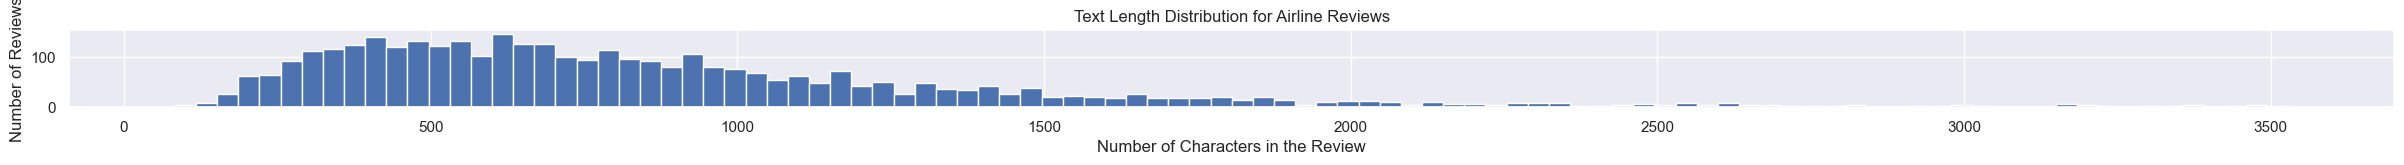

In [624]:
#2.2.3: Text Length Distribution Histogram

#Finds the number of characters for each review and stores them in a variable
text_len_hist_data=review_df["ReviewBody"].str.len()

#Create the histogram with enough bins to show the distribution clearly
plt.hist(text_len_hist_data,bins=100)
plt.xlabel("Number of Characters in the Review")
plt.ylabel("Number of Reviews")
plt.title("Text Length Distribution for Airline Reviews")

#Save the Figure as a .png file
#plt.savefig("text_length_distribution_hist.png")
plt.show()

In [625]:
text_len_hist_data.max()

3529

In [626]:
#2.3 Initial Observations
#2.3.1 What Language is it in

#The reviews are written in English.

#2.3.2 Do you see any HTML Tags?

#Looking at over 400 reviews, I have not encountered any HTML tags in the bodies of the reviews.However there are certain URLs that do not follow the typical structure
#(i.e. BA.com, UK.gov)

#2.3.3 Are there special characters?

#As mentioned in the last question, there are some URLs in the text that do not follow the standardized format. Also, there are some individual special characters that
#will need to be removed. Below are some of the cases that were in the initial dataset. This was fixed by using the encoding argument in the read CSV function for loading
#in the dataset. The encoding could have also included cp1252 or iso-8859-1 depending on what the dataset shows. There were no hashtags or emojis in the text.

#Special Characters

#Case id 3655 â€˜
#Case id 3654 â€œkeep tryingâ€ , â€“
#Case id 3634 contains $
#Case id 3613  Â£20
#Case id 3607 Â£1000
#Case id 3579 â€“
#Case id 3537 Â£240
#Case id 3513  anyoneâ€™s legs
#Case id 3500,3499 Â£120
#Case id 3411 Â£284

#2.3.4 Are there any obvious cleaning issues?

#There are some cleaning issues including the differentiating currency signs, but asides from that there weren't
# any obvious cleaning steps that could be applied to all of the reviews. The problem with this is that there is
# no uniform formatting within the reviews and it is written by different people from all over the world. This
# means that there are going to be some symbollic differences (i.e. $ and £). With that many reviews, people will
#also write in a style that is unique to them. This means that there will varying kinds of reviews.

#2.3.5 What patterns do you notice?

#I noticed that when people are writing their reviews, they will include the patter of their trip by listing their stops
# followed by a "-".

In [627]:
#Show an example of text with the special characters (This was fixed earlier when the encoding argument was added to the read_csv function)
review_df['ReviewBody'][3579]

'Club World–LGW to TPA week later MIA to LHR. Gatwick check in quick and easy BA member came over and pointed us through Fast Track and gave lounge instructions. Lounge food offering very disappointing compared to LHR made do with Marmite on toast and lots of Champagne! In celebratory mood as going for a 30th cabin crew outbound fantastic the drinks kept flowing and never a rolled eye or any surly attitude from the crew. Managed 4/5 hours afternoon nap. Upgraded WTP home bound to CW through AVIOS 24hrs before and even bagged upper deck. An amazing night flight left on time. Have always found UD crew fantastic two pre departure drinks and mixed fleet seemed genuinely flying to serve. Only downside was pretty terrible dinner - starter and salad dreadful steak main not much better. Requested tray be taken away and skip dessert. Reclined and slept - and got woken 6 hours later for a bacon roll. Landed at LHR on time through security four bags collected and out of airport in 25 minutes. Clu

In [628]:
#STEP 3: Text Cleaning Processes

#Step 3.1.1 and 3.1.2
#Function that removes any HTML Tags that may exist in the reviews
def clean_text(text):
    return BeautifulSoup(text, "html.parser").get_text()

#Removes any URLs that do not follow the typical format as is the case in this dataset.
def remove_url(text):
    return re.sub(r'\.(com|gov|net|org|edu)\b', '', text)

#Step 3.1.3
#Function that removes special characters from the text
def remove_spec_char(text):
    return re.sub(r'[^a-zA-Z0-9. ]', ' ', text)

#Step 3.1.4
#Function that expands contractions so we can properly vectorize
def expand_contractions_text(text):
    return contractions.fix(text)
               
#Step 3.1.6
#Text to remove any extra spaces in between and at the beginning of the text
def remove_extra_spaces(text):
    outer_space_clean=text.strip()
    final_clean= " ".join(text.split())
    return final_clean

#Step 3.1.7
#I am keeping the numbers because in some of these textual analyses the numbers help add to the polarity, emphasis, and more. 


In [629]:
#Takes the functions and creates a new column in the dataframe stores the cleaned text
review_df['clean_review'] = review_df['ReviewBody'].apply(clean_text)
review_df['clean_review']= review_df['clean_review'].apply(remove_url)
review_df['clean_review']= review_df['clean_review'].apply(expand_contractions_text)
review_df['clean_review']= review_df['clean_review'].apply(remove_spec_char)
review_df['clean_review']= review_df['clean_review'].apply(remove_extra_spaces)

#Step 3.1.5
#Make the text lowercase for analysis
review_df['clean_review']= review_df['clean_review'].str.lower()

C:\Users\ysass\AppData\Local\Temp\ipykernel_23308\3094603946.py:6: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  return BeautifulSoup(text, "html.parser").get_text()


In [630]:
#3.2 Spot Check Validation
#Create a random list for the spot check
rand_spot_check=random.sample(range(1, num_rows), 4)
print(rand_spot_check)
#Run a loop that will print the original review along with the cleaned review
for i in range(0, len(rand_spot_check) - 1):
    print(f"Original Review: {review_df['ReviewBody'][rand_spot_check[i]]}")
    print(f"Cleaned Review: {review_df['clean_review'][rand_spot_check[i]]}")

[3247, 1161, 2183, 929]
Original Review: VIE-LHR on Nov 29 on an Airbus 320 in Economy - straightforward evening point to point flight with a mixed fleet crew. Flight departed on time and landed ahead of time in Heathrow which is a rare thing these days. No luggage to check and web check-in was working fine. Plane featured the new slim seats which are a step back in both comfort and legroom. Mixed fleet FA's were pleasant however the service was not particularly well organized. It took them quite some time for the service to start and it took more than 30 minutes to get a drink after the sandwich has been served. On the other hand the bacon sandwich was actually good and full bar service was offered. Other than the “required service” of sandwich drink and duty free the crew was pretty much in hiding mode. Service not quite up to usual BA standards. BA uses a shared lounge in VIE which this time was quite busy but not overcrowded. Lounge as such is acceptable but far from great. Still b

In [631]:
#3.2 Spot Check Validation

#3.2.1 What was fixed?
print(f"Original Review: {review_df['ReviewBody'][rand_spot_check[0]]}") #In this case it was review 603
print(f"Cleaned Review: {review_df['clean_review'][rand_spot_check[0]]}")
print("What was fixed: Removed punctutation, lowercased all of the text-Ready for TextBlob, VADER, and Transformer")

print(f"Original Review: {review_df['ReviewBody'][rand_spot_check[1]]}") #In this case it was review 1510
print(f"Cleaned Review: {review_df['clean_review'][rand_spot_check[1]]}")
print("What was fixed: Removed punctutation, lowercased all of the text-Ready for TextBlob, VADER, and Transformer")

print(f"Original Review: {review_df['ReviewBody'][rand_spot_check[2]]}") #In this case it was review 1091
print(f"Cleaned Review: {review_df['clean_review'][rand_spot_check[2]]}")
print("What was fixed: Removed punctutation, lowercased all of the text-Ready for TextBlob, VADER, and Transformer")

Original Review: VIE-LHR on Nov 29 on an Airbus 320 in Economy - straightforward evening point to point flight with a mixed fleet crew. Flight departed on time and landed ahead of time in Heathrow which is a rare thing these days. No luggage to check and web check-in was working fine. Plane featured the new slim seats which are a step back in both comfort and legroom. Mixed fleet FA's were pleasant however the service was not particularly well organized. It took them quite some time for the service to start and it took more than 30 minutes to get a drink after the sandwich has been served. On the other hand the bacon sandwich was actually good and full bar service was offered. Other than the “required service” of sandwich drink and duty free the crew was pretty much in hiding mode. Service not quite up to usual BA standards. BA uses a shared lounge in VIE which this time was quite busy but not overcrowded. Lounge as such is acceptable but far from great. Still believe that BA offers on

In [632]:
#Step 3.3 Remove Edge Cases

#Check if there are any empty strings after cleaning
print(review_df['clean_review'].isna().sum())

#Create a column that shows the word count for each review
review_df['wordcount']=review_df['clean_review'].str.split().str.len()
# In this case the minimum word count for a review is 8

#Step 3.3 and Step 5.3 
#After reading the reviews, there are no language differences; therefore, there are no edge cases in this dataset. 

0


In [633]:
#Import the stopwords in sklearn
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Convert to sorted list for better readability
stopwords_list = sorted(list(ENGLISH_STOP_WORDS))

# Print the number of stopwords and the first 20 stopwords as a sample
print("Total Stopwords in Sklearn:", len(stopwords_list))
print("Sample Stopwords:", stopwords_list[:20])

Total Stopwords in Sklearn: 318
Sample Stopwords: ['a', 'about', 'above', 'across', 'after', 'afterwards', 'again', 'against', 'all', 'almost', 'alone', 'along', 'already', 'also', 'although', 'always', 'am', 'among', 'amongst', 'amoungst']


In [634]:
#Download the NLTK stopworks
nltk.download('stopwords') #need to download this pre-trained data for using with word tokenizer

#Store the NLTK stop words in a list in English
stop_words_nltk = list(stopwords.words('english')) #define English as the stop words

# Print the number of stopwords and the first 20 stopwords as a sample
print("Total Stopwords in NLTK:", len(stop_words_nltk))
print("Sample Stopwords:", stop_words_nltk[:20])

Total Stopwords in NLTK: 198
Sample Stopwords: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ysass\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [635]:
#Text Pre-Processing/Tokenization/Vectorization
#Convert the reviews into a matrix that shows the word counts for each word
vectorizer = CountVectorizer(stop_words='english', max_features=5000)  # remove stop words, Limit features to 5000 words
#Fit the vectorizer to the cleaned reviews
X = vectorizer.fit_transform(review_df['clean_review'])

In [636]:
# To read it, we need to transform the Matrix to an array, another mathematical representation

# Convert to an array for readability
X_array = X.toarray()

# Get feature names ( / terms)
feature_names = vectorizer.get_feature_names_out()

# Print vocabulary
print("Vocabulary / Terms (Features):")
print(feature_names)

# Print the vectorized form of the first sentence
print("\nFirst Sentence Vector: ", review_df['clean_review'][0])
print(X_array[0])  # First sentence in vector form

# Convert to a dictionary for better readability
vector_dict = dict(zip(feature_names, X_array[0]))
print("\nWord Frequency in First Sentence:")
print(vector_dict)

Vocabulary / Terms (Features):
['00' '000' '00am' ... 'zoo' 'zrh' 'zurich']

First Sentence Vector:  4 hours before takeoff we received a mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. so did the capacity of the heathrow airport really hit british airways by surprise 4h before departure anyhow we took the one hour delay so what but then we have been forced to check in our hand luggage. i travel only with hand luggage to avoid waiting for the ultra slow processing of the checked in luggage. overall 2h later at home than planed with really no reason just due to incompetent people. service level far worse then ryanair and triple the price. really never again. thanks for nothing.
[0 0 0 ... 0 0 0]

Word Frequency in First Sentence:
{'00': 0, '000': 0, '00am': 0, '01': 0, '03': 0, '05': 0, '06': 0, '07': 0, '08': 0, '09': 0, '10': 0, '100': 0, '1000': 0, '10000': 0, '10a': 0, '10am': 0, '10b': 0, '1

In [637]:
print(review_df['clean_review'][1])
print(X_array[0])

i recently had a delay on british airways from bru to lhr that was due to staff shortages. they announced that there was a 2 hour holding delay but they would board us immediately in hopes of clearing the gate and leaving early. we had to wait the full 2 hours inside the airplane. the plane was old dirty had no power at the seats. the staff provided a small bag of pretzels and 250ml of water to the passengers for 2 hour delay and 2 hour flight. there were no options to purchase food or drink. there were no entertainment options available. i am a oneworld emerald elite member but they do not upgrade members based on status. first class lounges at heathrow are overcrowded understaffed and poorly equipped. the help desk is completely unhelpful when an error arises with delays and cancellations even when having the top status. the avios points system has been devalued to near worthlessness and requires fees to book reward that nearly equal the price of the revenue ticket. british has lost 

In [638]:
#Going through each clean review and removing the stop words one by one and put together the completely clean review
for review in range(0, len(review_df)):
    a = review_df.clean_review[review].split()
    sentence=[ x for x in a  if x not in stop_words_nltk]
    review_df['clean_review'][review]=" ".join(sentence)

C:\Users\ysass\AppData\Local\Temp\ipykernel_23308\3249434317.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  review_df['clean_review'][review]=" ".join(sentence)
C:\Users\ysass\AppData\Local\Temp\ipykernel_23308\3249434317.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  review_df['clean_review'][review]=" ".join(sentence)
C:\Users\ysass\AppData\Local\Temp\ipykernel_23308\3249434317.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-c

In [639]:
review_df['clean_review']

Id
0       4 hours takeoff received mail stating cryptic ...
1       recently delay british airways bru lhr due sta...
2       boarded time took ages get runway due congesti...
3       5 days flight advised ba cancelled asked us re...
4       traveled lisbon dream vacation cruise portugal...
                              ...                        
3696    bmi regional operated flight rj145 manchester ...
3697    lhr ham. purser addresses club passengers name...
3698    son worked british airways urged fly british a...
3699    london city new york jfk via shannon a318 real...
3700    sin lhr ba12 b747 436 first class. old aircraf...
Name: clean_review, Length: 3701, dtype: object

In [640]:
#STEP 4: Tokenize, Feature Engineer, and Vectorize

#4.1 VADER Pipeline

#1. Load the text into the file
#2. Clean the text (i.e. remove certain special characters and grammatical characters)
#3. Preprocessing: Use certain methods such as tokenization and vectorization with CountVectorizer
#4. Apply the SentimentIntensityAnalyzer to the text to get the compound score.


#4.1.1 How does VADER tokenize?

#VADER tokenizes by taking the raw text it is presented and splits it into individual words, punctuation, and any other groupings of characters 
#that it can find in the text. It can either use nltk.word_tokenize or Count_Vectorizer to tokenize the words.

#4.1.2 What features does VADER use? 

#VADER uses a lexicon (seen in a block later in the code) that has a rating value between -4 to 4 for many possible words that might be encountered
#in a text. Another feature that VADER utilizes is the capitalization of letters. Words that are in all capital letters may have a higher score
#than a word with all lower case letters. Certain punctuation is another feature that can affect the overall score of the text. An example is that exclamation point
#can affect the score more than a period. It can also use emojis. The specific emoji can indicate positive or negative impact on the message and change the score. 

#4.1.3 What preprocessing does VADER expect?

#VADER requires very minimal preprocessing because certain elements that would be cleaned has an affect on the way VADER processes the text. An example
#of this includes capitalization, emojis, and punctuation. It is important to keep certain elements in the text for VADER, but other elements including certain special characters
#should be removed as some of them do not have an affect. VADER also requires text cleaning, vectorization, and tokenization. 

#4.2 Textblob Pipeline

#1. Import and Load text
#2. Text cleaning (removal of HTML tags, expanding contraction, removing special characters, removing extra whitespace)
#3. Pre-Processing (lowercasing, correct spelling)
#4. Apply TextBlob functions to tokenize (words or sentences), and then apply sentiment analysis.

#4.2.1 How does Textblob tokenize?

#Textblob tokenizes by using two very specific functions to break down the text into smaller units. They can either use .words or .sentences methods within the Textblob
#library. These functions use the punctuation from the sentences or the whitespace depending on how deep they want to tokenize. 

#4.2.2 What features does Textblob use? 

#

#4.2.3 What preprocessing does Textblob expect?



# 4.3 Transformer Pipeline

#1. Import and load the data into a table
#2. Make sure that the text is clean.
#3. Initalize the Tokenizer that the text will be using with the AutoTokenizer function and base it off of the specific model we are looking at (in this case distilbert-base-uncased-emotion)
#4. Initialize the model so we can apply it once the classifier is established
#5. Establish and initialize the classifier using the model and tokenizer that was decided upon earlier
#6. Apply the function to the dataset to produce the emotion and score from the text

#4.3.1 How does distilbert-base-uncased-emotion tokenize? 

#distilbert-base-uncased-emotion tokenizes by breaking down the text into individual words and then breaks down those words into smaller parts that will help the text be more easily understood.
#This is meant for a very short set of texts 

#4.3.2 What features does distilbert use?



#4.3.3 What preprocessing does distilbert expect?

#distilbert expects that the text be lowercased, tokenized, converting the numerical values from tokenization into input id's and the option to ensure that all sentences or texts are the same length. 


#4.4 Key Differences

# 4.4.1 Document any differences in Tokenization approach 

#First they conduct the same processes when it comes to tokenization from both options. Both VADER and Textblob can tokenize by identifying individual elements
#to help determine sentiment. However, a major notable difference is that the VADER and TextBlob libraries have their own specific functions that handle tokenization.
#Another fundamental difference is that VADER is able to take other forms of text including emojis and punctuation into sentiment analysis, while Textblob is specifically
#for text only. #Another key difference is that the distilbert model requires that the text be broken down at a subtokenization level. 

#4.4.2 Document any differences in Feature engineering 

#4.4.3 Document any differences in Vectorization 

#When it is being vectorized, VADER is able to handle the smaller text and unknown words/slang because it was initially meant to be used for social media analysis. When
#looking at Texblob, it can be used on text mainly; however, when it sees words that it doesn't know in the tokenization it will be skipped over during the vectorization process. 

#4.4.4 Document any differences in Preprocessing requirements

#Since VADER relies on capitalization and punctuation to help determine the sentiment, we do not need to remove punctuation or lowercase text
# for VADER. For Textblob, it is important that all of the text is lowercased. 



In [641]:
#STEP 5: Apply Pretrained Models

#5.1 VADER Implelmentation

#Download the lexicon that vader uses to score its text
nltk.download('vader_lexicon')

#Initialize the Sentiment Intensity Analyzer so we can get sentiment ratings for each review
sid = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ysass\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [642]:
#Create a section of the dataframe that shows the reviews with the best (10.0) or worst (1.0) ratings and reset the index so we can index off of that list
reviews_best_worst = review_df[(review_df["OverallRating"]==10.0) | (review_df["OverallRating"]==1.0)].reset_index()

In [643]:
reviews_best_worst

,Id,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,...,CabinStaffService,GroundService,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity,clean_review,wordcount
0,0,1.0,"""Service level far worse then Ryanair""",L Keele,19th November 2023,True,4 Hours before takeoff we received a Mail stat...,Couple Leisure,Economy Class,London to Stuttgart,...,1.0,1.0,1.0,no,NaN,NaN,NaN,NaN,4 hours takeoff received mail stating cryptic ...,123
1,3,1.0,"""Absolutely hopeless airline""",Nigel Dean,16th November 2023,True,"5 days before the flight, we were advised by B...",Couple Leisure,Economy Class,London to Dublin,...,3.0,1.0,1.0,no,NaN,NaN,NaN,NaN,5 days flight advised ba cancelled asked us re...,256
2,4,1.0,"""Customer Service is non existent""",Gaylynne Simpson,14th November 2023,False,"We traveled to Lisbon for our dream vacation, ...",Couple Leisure,Economy Class,London to Lisbon,...,1.0,1.0,1.0,no,NaN,1.0,1.0,1.0,traveled lisbon dream vacation cruise portugal...,175
3,5,1.0,"""I can’t imagine a worst airline""",A Narden,12th November 2023,True,Booked a flight from Bucharest to Manchester w...,Solo Leisure,Economy Class,Bucharest to Manchester via London,...,1.0,1.0,1.0,no,A320,1.0,1.0,NaN,booked flight bucharest manchester 2h 45 layov...,205
4,11,1.0,“BA clearly does not care”,J Furlong,31st October 2023,True,1. Ground crew in Heathrow left 60 passengers ...,Couple Leisure,Economy Class,Anchorage to Heathrow via Barcelona,...,3.0,1.0,1.0,no,NaN,3.0,3.0,3.0,1. ground crew heathrow left 60 passengers lug...,232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1190,3681,10.0,British Airways customer review,C Denson,5th May 2014,False,Chicago O'Hare to London Heathrow on 2 May. ch...,NaN,Economy Class,NaN,...,5.0,NaN,5.0,yes,NaN,5.0,4.0,NaN,chicago hare london heathrow 2 may. check fast...,37
1191,3682,10.0,British Airways customer review,A Hickling,4th May 2014,False,Travelled to HKG on board the new A380. Boardi...,NaN,First Class,NaN,...,5.0,NaN,5.0,yes,NaN,5.0,5.0,NaN,travelled hkg board new a380. boarding efficie...,187
1192,3683,1.0,British Airways customer review,Iain Henderson,3rd May 2014,False,BA 059 London to Cape Town April 29 2014 econo...,NaN,Economy Class,NaN,...,1.0,NaN,1.0,no,NaN,1.0,1.0,NaN,ba 059 london cape town april 29 2014 economy....,143
1193,3693,10.0,British Airways customer review,J Tinning,29th August 2012,False,Flew LHR - VIE return operated by bmi but BA a...,NaN,Economy Class,NaN,...,5.0,NaN,4.0,yes,NaN,5.0,NaN,NaN,flew lhr vie return operated bmi ba aircraft. ...,81


In [644]:
review_df.sample(10)

,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,DateFlown,...,CabinStaffService,GroundService,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity,clean_review,wordcount
Id,,,,,,,,,,,,,,,,,,,,,
3650,10.0,British Airways customer review,Michael Davies,20th May 2014,False,London Heathrow to Madrid on a Boeing 767-300....,NaN,Business Class,NaN,NaN,...,5.0,NaN,5.0,yes,NaN,5.0,1.0,NaN,london heathrow madrid boeing 767 300. outward...,132
1583,2.0,"""now providing a very inferior product""",B Saunders,27th June 2017,False,Flew British Airways from Beijing to London He...,Business,Business Class,Beijing to London Heathrow,Jun-17,...,2.0,2.0,2.0,no,Boeing 777,1.0,1.0,NaN,flew british airways beijing london heathrow. ...,291
3465,6.0,British Airways customer review,Russ King,1st September 2014,False,BA15 LHR to SIN B777-300ER First Class: nice a...,NaN,First Class,NaN,NaN,...,5.0,NaN,2.0,no,NaN,5.0,3.0,NaN,ba15 lhr sin b777 300er first class nice four ...,192
2507,10.0,"""adequate inflight service""",A Bailey,14th December 2015,False,"Full flight efficient boarding, friendly greet...",Business,Economy Class,Newcastle to Heathrow,Dec-15,...,5.0,5.0,5.0,yes,A319,NaN,NaN,NaN,full flight efficient boarding friendly greeti...,45
2241,4.0,"""have let their standards slip""",Annika Evans,3rd June 2016,False,London Heathrow to Miami with British Airways....,Family Leisure,Economy Class,LHR to MIA,May-16,...,2.0,2.0,3.0,no,Boeing 747-400,2.0,1.0,1.0,london heathrow miami british airways. used hu...,120
2151,5.0,"""hope this experience is not repeated""",H Porter,16th August 2016,False,London Heathrow to Istanbul return. The outbou...,Family Leisure,Economy Class,LHR to IST,Aug-16,...,5.0,4.0,3.0,no,NaN,1.0,3.0,NaN,london heathrow istanbul return. outbound flig...,164
2225,8.0,"""cabin crew were excellent""",Mark Dobson,14th June 2016,False,Very good flight back to London from Barbados....,Solo Leisure,Business Class,BGI to LGW,May-16,...,5.0,5.0,4.0,yes,Boeing 777,4.0,4.0,NaN,good flight back london barbados. bridgetown b...,204
434,1.0,"""can't be reached on the phone""",A Burran,11th March 2022,True,"British Airways is getting worse an worse, my ...",Business,Economy Class,Copenhagen to London,Mar-22,...,2.0,1.0,1.0,no,NaN,1.0,NaN,NaN,british airways getting worse worse flight 8 m...,72
466,7.0,"""seats are a huge improvement""",David Ellis,2nd January 2022,True,After two years of being unable to fly to our ...,Couple Leisure,Business Class,London to Cape Town,Dec-21,...,3.0,4.0,3.0,yes,Boeing 777,2.0,5.0,1.0,two years unable fly second home south africa ...,200


In [645]:
#Shows the 1st review along with the polarity score using the VADER method.
print(reviews_best_worst.loc[1.0, 'ReviewBody'])
print()
sid.polarity_scores(reviews_best_worst.loc[1.0, 'ReviewBody'])

5 days before the flight, we were advised by BA that it had been cancelled and asked us to rebook. There were flights 1 hour before and 1 hour after our original flight but they made us take one 3 hours earlier. Our original ticket (and the return flight a week later) included a checked bag. When we arrive at Heathrow to check in we are told our ticket doesn't included a bag and we will have to pay 75 pounds each to take them. We explained that the original ticket had the bags and when they checked the system they confirmed that it did- but not this one! They would make no effort to sort it out and just told us to pay up or they would remove us from the flight. So we had no choice but to pay up, thinking it should be pretty easy to get a refund. 15 months and 10 emails later we have still not seen a penny. Every time I ask where my refund is and state how long we have been waiting I get an inane email saying some departments take longer than others to respond!  Absolutely hopeless airl

{'neg': 0.102, 'neu': 0.833, 'pos': 0.066, 'compound': -0.8327}

In [646]:
print(reviews_best_worst.loc[10.0, 'ReviewBody'])
print()
sid.polarity_scores(reviews_best_worst.loc[10.0, 'ReviewBody'])

They downgraded me from business to premium economy. They took three months to get back to me and offered me 200 pounds or 400 AUD. The difference between business class and premium economy (which I never fly) is $3000 AUD and the difference between economy and business is $6500 AUD. They owe me at least 1500 pounds and to be very fair 3250 pounds. The downgrade was insulting and incredibly painful as I had a recent cancer operation and have a back injury which I have pointed out to them - I need to lie down. The wait for them to get around to me has been numbing. The insult of their offer has been the slap in the face to continue my degradation. The people I have dealt with at the airport have been down to earth, honest hard working people. The actual staff on the plane were warm and friendly - and helpful. The systems under which BA operates are some sort of medieval torture.



{'neg': 0.15, 'neu': 0.767, 'pos': 0.083, 'compound': -0.9273}

In [647]:
#Shows the worst reviews
reviews_best_worst[reviews_best_worst["OverallRating"]==1.0]

,Id,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,...,CabinStaffService,GroundService,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity,clean_review,wordcount
0,0,1.0,"""Service level far worse then Ryanair""",L Keele,19th November 2023,True,4 Hours before takeoff we received a Mail stat...,Couple Leisure,Economy Class,London to Stuttgart,...,1.0,1.0,1.0,no,NaN,NaN,NaN,NaN,4 hours takeoff received mail stating cryptic ...,123
1,3,1.0,"""Absolutely hopeless airline""",Nigel Dean,16th November 2023,True,"5 days before the flight, we were advised by B...",Couple Leisure,Economy Class,London to Dublin,...,3.0,1.0,1.0,no,NaN,NaN,NaN,NaN,5 days flight advised ba cancelled asked us re...,256
2,4,1.0,"""Customer Service is non existent""",Gaylynne Simpson,14th November 2023,False,"We traveled to Lisbon for our dream vacation, ...",Couple Leisure,Economy Class,London to Lisbon,...,1.0,1.0,1.0,no,NaN,1.0,1.0,1.0,traveled lisbon dream vacation cruise portugal...,175
3,5,1.0,"""I can’t imagine a worst airline""",A Narden,12th November 2023,True,Booked a flight from Bucharest to Manchester w...,Solo Leisure,Economy Class,Bucharest to Manchester via London,...,1.0,1.0,1.0,no,A320,1.0,1.0,NaN,booked flight bucharest manchester 2h 45 layov...,205
4,11,1.0,“BA clearly does not care”,J Furlong,31st October 2023,True,1. Ground crew in Heathrow left 60 passengers ...,Couple Leisure,Economy Class,Anchorage to Heathrow via Barcelona,...,3.0,1.0,1.0,no,NaN,3.0,3.0,3.0,1. ground crew heathrow left 60 passengers lug...,232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1184,3654,1.0,British Airways customer review,C Tyler,18th May 2014,False,When we booked our holiday to Barbados I was r...,NaN,Economy Class,NaN,...,2.0,NaN,2.0,no,NaN,1.0,1.0,NaN,booked holiday barbados really pleased see fly...,479
1185,3662,1.0,British Airways customer review,Kathleen Osborne,12th May 2014,False,I should be in a nice hotel in Romania instead...,NaN,Economy Class,NaN,...,1.0,NaN,1.0,no,NaN,3.0,1.0,NaN,nice hotel romania instead 9 hours arrived hea...,280
1189,3676,1.0,British Airways customer review,P Harris,7th May 2014,False,Lanzarote to Gatwick on 13th April. Flight its...,NaN,Economy Class,NaN,...,3.0,NaN,2.0,no,NaN,3.0,1.0,NaN,lanzarote gatwick 13th april. flight okay arri...,132
1192,3683,1.0,British Airways customer review,Iain Henderson,3rd May 2014,False,BA 059 London to Cape Town April 29 2014 econo...,NaN,Economy Class,NaN,...,1.0,NaN,1.0,no,NaN,1.0,1.0,NaN,ba 059 london cape town april 29 2014 economy....,143


In [648]:
print(reviews_best_worst.loc[1194, 'clean_review'])
print()
sid.polarity_scores(reviews_best_worst.loc[1194, 'clean_review'])

bmi regional operated flight rj145 manchester heathrow ba flight number report here. boarding cabin crew member look check boarding passes welcome us. check seatbelts etc. prior takeoff. service started soon takeoff since short flight consisted trolley drinks snacks usual ba domestic services. 5 men front returning weekend break given 2 gin tonics cabin steward friendly them. got stared stared back took forgotten say may offer something bar something similar. asked orange juice exactly thrust onto tray. asked ice got one lump splashed juice reluctantly. none rest us offered drink expect short flight. goodbye departure grimace surprise me. sad see bmi staff lost sense pride jobs.



{'neg': 0.092, 'neu': 0.804, 'pos': 0.104, 'compound': 0.3182}

In [649]:
sns.set(rc={'figure.figsize':(30,1)})

def visualise_sentiments(data):
  sns.heatmap(pd.DataFrame(data).set_index("Sentence").T,center=0, annot=True, cmap = "PiYG")

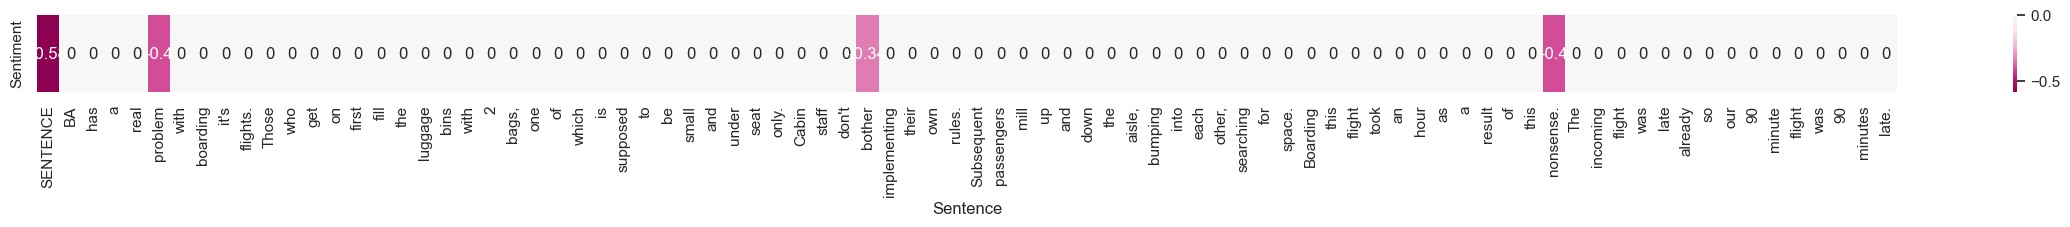

In [650]:
visualise_sentiments({
    "Sentence":["SENTENCE"] + reviews_best_worst.loc[12, 'ReviewBody'].split(),
    "Sentiment":[sid.polarity_scores(reviews_best_worst.loc[12, 'ReviewBody'])["compound"]]
    + [sid.polarity_scores(word)["compound"] for word in reviews_best_worst.loc[12, 'ReviewBody'].split()]
})

In [651]:
# create a new DataFrame column for compound
review_df['vader_compound_score'] = review_df['clean_review'].apply(sid.polarity_scores)
review_df.head(2)

,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,DateFlown,...,GroundService,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity,clean_review,wordcount,vader_compound_score
Id,,,,,,,,,,,,,,,,,,,,,
0,1.0,"""Service level far worse then Ryanair""",L Keele,19th November 2023,True,4 Hours before takeoff we received a Mail stat...,Couple Leisure,Economy Class,London to Stuttgart,Nov-23,...,1.0,1.0,no,NaN,NaN,NaN,NaN,4 hours takeoff received mail stating cryptic ...,123,"{'neg': 0.245, 'neu': 0.653, 'pos': 0.103, 'co..."
1,3.0,"""do not upgrade members based on status""",Austin Jones,19th November 2023,True,I recently had a delay on British Airways from...,Business,Economy Class,Brussels to London,Nov-23,...,1.0,2.0,no,A320,1.0,2.0,2.0,recently delay british airways bru lhr due sta...,206,"{'neg': 0.151, 'neu': 0.743, 'pos': 0.106, 'co..."


In [652]:
#Convert raw sentiment output into positive negative

def return_sentiment_prediction_vader(text):
    polarity_score=sid.polarity_scores(text)['compound']
    if polarity_score>0.5:
        result="Positive"
    elif polarity_score >-0.5 and polarity_score<0.5:
        result="Neutral"
    else:
        result="Negative"
    return result


#Start timer
start_time_vader = time.perf_counter()


#Text Pre-Processing/Tokenization/Vectorization
#Convert the reviews into a matrix that shows the word counts for each word
vectorizer = CountVectorizer(stop_words='english', max_features=5000)  # remove stop words, Limit features to 5000 words
#Fit the vectorizer to the cleaned reviews
X = vectorizer.fit_transform(review_df['clean_review'])

review_df['vader_prediction'] = review_df['clean_review'].apply(return_sentiment_prediction_vader)

#End Timer
end_time_vader = time.perf_counter()
elapsed_time_vader = end_time_vader - start_time_vader
print(f"Execution time: {elapsed_time_vader:.4f} seconds")

Execution time: 6.9119 seconds


In [653]:
review_df

,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,DateFlown,...,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity,clean_review,wordcount,vader_compound_score,vader_prediction
Id,,,,,,,,,,,,,,,,,,,,,
0,1.0,"""Service level far worse then Ryanair""",L Keele,19th November 2023,True,4 Hours before takeoff we received a Mail stat...,Couple Leisure,Economy Class,London to Stuttgart,Nov-23,...,1.0,no,NaN,NaN,NaN,NaN,4 hours takeoff received mail stating cryptic ...,123,"{'neg': 0.245, 'neu': 0.653, 'pos': 0.103, 'co...",Negative
1,3.0,"""do not upgrade members based on status""",Austin Jones,19th November 2023,True,I recently had a delay on British Airways from...,Business,Economy Class,Brussels to London,Nov-23,...,2.0,no,A320,1.0,2.0,2.0,recently delay british airways bru lhr due sta...,206,"{'neg': 0.151, 'neu': 0.743, 'pos': 0.106, 'co...",Negative
2,8.0,"""Flight was smooth and quick""",M A Collie,16th November 2023,False,"Boarded on time, but it took ages to get to th...",Couple Leisure,Business Class,London Heathrow to Dublin,Nov-23,...,3.0,yes,A320,4.0,NaN,NaN,boarded time took ages get runway due congesti...,54,"{'neg': 0.0, 'neu': 0.914, 'pos': 0.086, 'comp...",Neutral
3,1.0,"""Absolutely hopeless airline""",Nigel Dean,16th November 2023,True,"5 days before the flight, we were advised by B...",Couple Leisure,Economy Class,London to Dublin,Dec-22,...,1.0,no,NaN,NaN,NaN,NaN,5 days flight advised ba cancelled asked us re...,256,"{'neg': 0.126, 'neu': 0.769, 'pos': 0.105, 'co...",Neutral
4,1.0,"""Customer Service is non existent""",Gaylynne Simpson,14th November 2023,False,"We traveled to Lisbon for our dream vacation, ...",Couple Leisure,Economy Class,London to Lisbon,Nov-23,...,1.0,no,NaN,1.0,1.0,1.0,traveled lisbon dream vacation cruise portugal...,175,"{'neg': 0.025, 'neu': 0.86, 'pos': 0.115, 'com...",Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3696,1.0,British Airways customer review,J Robertson,29th August 2012,False,This was a bmi Regional operated flight on a R...,NaN,Economy Class,NaN,NaN,...,3.0,no,NaN,2.0,NaN,NaN,bmi regional operated flight rj145 manchester ...,226,"{'neg': 0.092, 'neu': 0.804, 'pos': 0.104, 'co...",Neutral
3697,9.0,British Airways customer review,Nick Berry,28th August 2012,False,LHR to HAM. Purser addresses all club passenge...,NaN,Business Class,NaN,NaN,...,3.0,yes,NaN,4.0,NaN,NaN,lhr ham. purser addresses club passengers name...,25,"{'neg': 0.0, 'neu': 0.708, 'pos': 0.292, 'comp...",Positive
3698,5.0,British Airways customer review,Avril Barclay,12th October 2011,False,My son who had worked for British Airways urge...,NaN,Economy Class,NaN,NaN,...,4.0,yes,NaN,NaN,NaN,NaN,son worked british airways urged fly british a...,231,"{'neg': 0.066, 'neu': 0.813, 'pos': 0.12, 'com...",Positive


In [654]:
#5.2 Implementing TextBlob
# define a function that accepts text and returns the polarity
def detect_sentiment(text):

    #Converts the text into textblob object and then retuns
    #the subjectivity.
    blob = TextBlob(text)

    # return the polarity and subjectivity
    return blob.sentiment

def detect_subjectivity(text):

    #Converts the text into textblob object and then retuns
    #the subjectivity.
    blob = TextBlob(text)

    # return the polarity and subjectivity
    return blob.sentiment.subjectivity

In [655]:
#Start timer
start_time_textblob = time.perf_counter()

vectorizer = CountVectorizer(stop_words='english', max_features=5000)  # remove stop words, Limit features to 5000 words
#Fit the vectorizer to the cleaned reviews
X = vectorizer.fit_transform(review_df['clean_review'])
review_df["TextBlob_Analysis (Polarity, Subjectivity)"] = review_df.clean_review.apply(detect_sentiment)
review_df["TextBlob_Analysis (Subjectivity)"] = review_df.clean_review.apply(detect_subjectivity)

#End Timer
end_time_textblob = time.perf_counter()
elapsed_time_textblob = end_time_textblob - start_time_textblob
print(f"Execution time: {elapsed_time_textblob:.4f} seconds")

Execution time: 8.0609 seconds


In [656]:
#Use Polarity to determine if the text is positive or negative

def return_sentiment_prediction_textblob(text):
    raw_text=TextBlob(text)
    polarity_score=raw_text.sentiment.polarity
    if polarity_score>0:
        result="Positive"
    elif polarity_score <0:
        result="Negative"
    else:
        result="Neutral"
    return result

review_df['textblob_prediction'] = review_df['clean_review'].apply(return_sentiment_prediction_textblob)

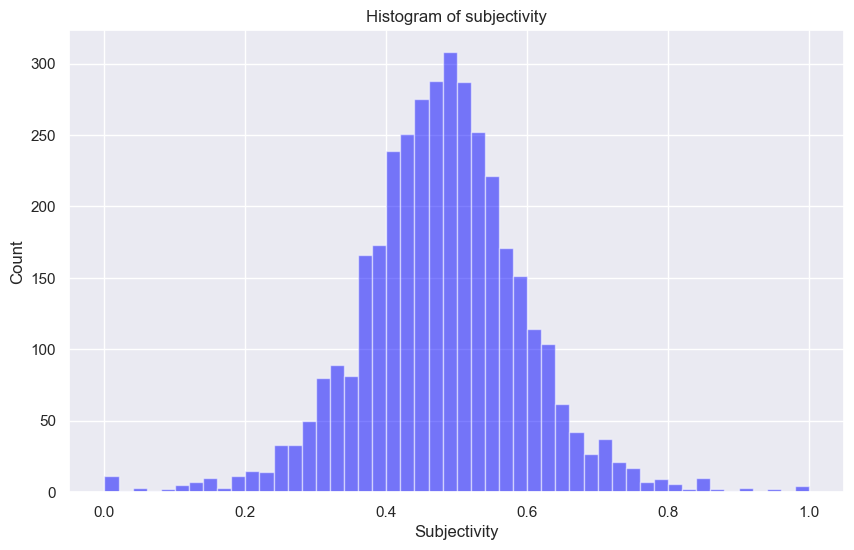

In [657]:
#Draw a histogram that shows the distribution of subjectivity: Count vs. subjectivity
num_bins = 50
plt.figure(figsize=(10,6))
n, bins, patches = plt.hist(review_df['TextBlob_Analysis (Subjectivity)'], num_bins, facecolor='blue', alpha=0.5)
plt.xlabel('Subjectivity')
plt.ylabel('Count')
plt.title('Histogram of subjectivity')
plt.show()

In [658]:
review_df

,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,DateFlown,...,Food&Beverages,InflightEntertainment,Wifi&Connectivity,clean_review,wordcount,vader_compound_score,vader_prediction,"TextBlob_Analysis (Polarity, Subjectivity)",TextBlob_Analysis (Subjectivity),textblob_prediction
Id,,,,,,,,,,,,,,,,,,,,,
0,1.0,"""Service level far worse then Ryanair""",L Keele,19th November 2023,True,4 Hours before takeoff we received a Mail stat...,Couple Leisure,Economy Class,London to Stuttgart,Nov-23,...,NaN,NaN,NaN,4 hours takeoff received mail stating cryptic ...,123,"{'neg': 0.245, 'neu': 0.653, 'pos': 0.103, 'co...",Negative,"(-0.03166666666666666, 0.30944444444444447)",0.309444,Negative
1,3.0,"""do not upgrade members based on status""",Austin Jones,19th November 2023,True,I recently had a delay on British Airways from...,Business,Economy Class,Brussels to London,Nov-23,...,1.0,2.0,2.0,recently delay british airways bru lhr due sta...,206,"{'neg': 0.151, 'neu': 0.743, 'pos': 0.106, 'co...",Negative,"(0.006944444444444438, 0.36712962962962964)",0.367130,Positive
2,8.0,"""Flight was smooth and quick""",M A Collie,16th November 2023,False,"Boarded on time, but it took ages to get to th...",Couple Leisure,Business Class,London Heathrow to Dublin,Nov-23,...,4.0,NaN,NaN,boarded time took ages get runway due congesti...,54,"{'neg': 0.0, 'neu': 0.914, 'pos': 0.086, 'comp...",Neutral,"(0.1408333333333333, 0.3775)",0.377500,Positive
3,1.0,"""Absolutely hopeless airline""",Nigel Dean,16th November 2023,True,"5 days before the flight, we were advised by B...",Couple Leisure,Economy Class,London to Dublin,Dec-22,...,NaN,NaN,NaN,5 days flight advised ba cancelled asked us re...,256,"{'neg': 0.126, 'neu': 0.769, 'pos': 0.105, 'co...",Neutral,"(0.1138888888888889, 0.5782539682539682)",0.578254,Positive
4,1.0,"""Customer Service is non existent""",Gaylynne Simpson,14th November 2023,False,"We traveled to Lisbon for our dream vacation, ...",Couple Leisure,Economy Class,London to Lisbon,Nov-23,...,1.0,1.0,1.0,traveled lisbon dream vacation cruise portugal...,175,"{'neg': 0.025, 'neu': 0.86, 'pos': 0.115, 'com...",Positive,"(0.13541666666666666, 0.29444444444444445)",0.294444,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3696,1.0,British Airways customer review,J Robertson,29th August 2012,False,This was a bmi Regional operated flight on a R...,NaN,Economy Class,NaN,NaN,...,2.0,NaN,NaN,bmi regional operated flight rj145 manchester ...,226,"{'neg': 0.092, 'neu': 0.804, 'pos': 0.104, 'co...",Neutral,"(0.06136363636363637, 0.3636363636363636)",0.363636,Positive
3697,9.0,British Airways customer review,Nick Berry,28th August 2012,False,LHR to HAM. Purser addresses all club passenge...,NaN,Business Class,NaN,NaN,...,4.0,NaN,NaN,lhr ham. purser addresses club passengers name...,25,"{'neg': 0.0, 'neu': 0.708, 'pos': 0.292, 'comp...",Positive,"(0.1732142857142857, 0.42857142857142855)",0.428571,Positive
3698,5.0,British Airways customer review,Avril Barclay,12th October 2011,False,My son who had worked for British Airways urge...,NaN,Economy Class,NaN,NaN,...,NaN,NaN,NaN,son worked british airways urged fly british a...,231,"{'neg': 0.066, 'neu': 0.813, 'pos': 0.12, 'com...",Positive,"(0.11354166666666667, 0.25625)",0.256250,Positive


In [659]:
#5.3 Transformer 
from transformers import AutoTokenizer, AutoModelForSequenceClassification
tokenizer = AutoTokenizer.from_pretrained("bhadresh-savani/distilbert-base-uncased-emotion")
model = AutoModelForSequenceClassification.from_pretrained("bhadresh-savani/distilbert-base-uncased-emotion")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [660]:
from transformers import pipeline
classifier = pipeline("text-classification",model='bhadresh-savani/distilbert-base-uncased-emotion', return_all_scores=True)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [661]:
#timer starts here
start_time_transformer = time.perf_counter()

texts = review_df["clean_review"].fillna("").astype(str).tolist()

batch_size = 32  # try 16/32/64 depending on RAM/GPU
all_out = []

for i in range(0, len(texts), batch_size):
    batch = texts[i:i+batch_size]
    out = classifier(batch, truncation=True)   # pipeline returns list[dict]
    all_out.extend(out)

review_df["Transformer_Prediction"] = [d["label"] for d in all_out]
review_df["Transformer_Score"] = [d["score"] for d in all_out]

#Timer Ends Here
end_time_transformer = time.perf_counter()
elapsed_time_transformer = end_time_transformer - start_time_transformer
print(f"Execution time: {elapsed_time_textblob:.4f} seconds")

Execution time: 440.7331 seconds


In [662]:
def transformer_label(text):
    #Categorize the transformer outputs into the positive negative and neutral categories
    positive_emotions = {"joy", "love"}
    negative_emotions = {"anger", "sadness", "fear"}
    neutral_emotions = {"surprise"}

    #Assign labels based on the output from the transformer
    if text in positive_emotions:
        return "Positive"
    elif text in negative_emotions:
        return "Negative"
    elif text in neutral_emotions:
        return "Neutral"
    else:
        return "Neutral"  # In case there is an updated label that the transformer did not include in the initial output

review_df['Transformer_Prediction_Specified'] = review_df['Transformer_Prediction'].apply(transformer_label)

In [663]:
tokenizer

BertTokenizer(name_or_path='bhadresh-savani/distilbert-base-uncased-emotion', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [401]:
review_df

,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,DateFlown,...,clean_review,wordcount,vader_compound_score,vader_prediction,"TextBlob_Analysis (Polarity, Subjectivity)",TextBlob_Analysis (Subjectivity),textblob_prediction,Transformer_Prediction,Transformer_Score,Transformer_Prediction_Specified
Id,,,,,,,,,,,,,,,,,,,,,
0,1.0,"""Service level far worse then Ryanair""",L Keele,19th November 2023,True,4 Hours before takeoff we received a Mail stat...,Couple Leisure,Economy Class,London to Stuttgart,Nov-23,...,4 hours takeoff received mail stating cryptic ...,123,"{'neg': 0.245, 'neu': 0.653, 'pos': 0.103, 'co...",Negative,"(-0.03166666666666666, 0.30944444444444447)",0.309444,Negative,fear,0.506497,Negative
1,3.0,"""do not upgrade members based on status""",Austin Jones,19th November 2023,True,I recently had a delay on British Airways from...,Business,Economy Class,Brussels to London,Nov-23,...,recently delay british airways bru lhr due sta...,206,"{'neg': 0.151, 'neu': 0.743, 'pos': 0.106, 'co...",Negative,"(0.006944444444444438, 0.36712962962962964)",0.367130,Positive,sadness,0.949061,Negative
2,8.0,"""Flight was smooth and quick""",M A Collie,16th November 2023,False,"Boarded on time, but it took ages to get to th...",Couple Leisure,Business Class,London Heathrow to Dublin,Nov-23,...,boarded time took ages get runway due congesti...,54,"{'neg': 0.0, 'neu': 0.914, 'pos': 0.086, 'comp...",Neutral,"(0.1408333333333333, 0.3775)",0.377500,Positive,joy,0.956077,Positive
3,1.0,"""Absolutely hopeless airline""",Nigel Dean,16th November 2023,True,"5 days before the flight, we were advised by B...",Couple Leisure,Economy Class,London to Dublin,Dec-22,...,5 days flight advised ba cancelled asked us re...,256,"{'neg': 0.126, 'neu': 0.769, 'pos': 0.105, 'co...",Neutral,"(0.1138888888888889, 0.5782539682539682)",0.578254,Positive,sadness,0.987168,Negative
4,1.0,"""Customer Service is non existent""",Gaylynne Simpson,14th November 2023,False,"We traveled to Lisbon for our dream vacation, ...",Couple Leisure,Economy Class,London to Lisbon,Nov-23,...,traveled lisbon dream vacation cruise portugal...,175,"{'neg': 0.025, 'neu': 0.86, 'pos': 0.115, 'com...",Positive,"(0.13541666666666666, 0.29444444444444445)",0.294444,Positive,anger,0.989388,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3696,1.0,British Airways customer review,J Robertson,29th August 2012,False,This was a bmi Regional operated flight on a R...,NaN,Economy Class,NaN,NaN,...,bmi regional operated flight rj145 manchester ...,226,"{'neg': 0.092, 'neu': 0.804, 'pos': 0.104, 'co...",Neutral,"(0.06136363636363637, 0.3636363636363636)",0.363636,Positive,joy,0.789725,Positive
3697,9.0,British Airways customer review,Nick Berry,28th August 2012,False,LHR to HAM. Purser addresses all club passenge...,NaN,Business Class,NaN,NaN,...,lhr ham. purser addresses club passengers name...,25,"{'neg': 0.0, 'neu': 0.708, 'pos': 0.292, 'comp...",Positive,"(0.1732142857142857, 0.42857142857142855)",0.428571,Positive,joy,0.997770,Positive
3698,5.0,British Airways customer review,Avril Barclay,12th October 2011,False,My son who had worked for British Airways urge...,NaN,Economy Class,NaN,NaN,...,son worked british airways urged fly british a...,231,"{'neg': 0.066, 'neu': 0.813, 'pos': 0.12, 'com...",Positive,"(0.11354166666666667, 0.25625)",0.256250,Positive,joy,0.568958,Positive


In [402]:
#STEP 6: Analyze and Review Results

#6.1 Random Row Reviews
sample_set=review_df.sample(100, random_state=5)
#Export sample rows to a csv file
sample_set.to_csv('airline_review_sample_data.csv')

In [456]:
#Read the analyzed csv file into the code
analyzed_sample_df=pd.read_csv(r"C:\Users\ysass\OneDrive\Desktop\Grad School Files\BSAN 6200 Text Mining and Social Media Analytics\text-analytics-spring-2026\assignment1\notebooks\airline_review_sample_data.csv",header=0, index_col='Id', encoding="utf-8")

In [714]:
#6.2 Accuracy Report

#Comparing Accuracy of the Models Based on the Performance from the Sample Dataset
print("VADER Accuracy:", accuracy_score(analyzed_sample_df['real_y'], analyzed_sample_df["vader_prediction"]))
print("TextBlob Accuracy:", accuracy_score(analyzed_sample_df['real_y'], analyzed_sample_df["textblob_prediction"]))
print("Transformer Accuracy:", accuracy_score(analyzed_sample_df['real_y'], analyzed_sample_df["Transformer_Prediction_Specified"]))

#Shows other performance metrics that the models have based on the sample data set
print("VADER Report:", classification_report(analyzed_sample_df['real_y'], analyzed_sample_df["vader_prediction"]))
print("TextBlob Report:", classification_report(analyzed_sample_df['real_y'], analyzed_sample_df["textblob_prediction"]))
print("Transformer Report:", classification_report(analyzed_sample_df['real_y'], analyzed_sample_df["Transformer_Prediction_Specified"]))

VADER Accuracy: 0.59
TextBlob Accuracy: 0.58
Transformer Accuracy: 0.77
VADER Report:               precision    recall  f1-score   support

    Negative       1.00      0.36      0.53        58
     Neutral       0.10      0.50      0.16         4
    Positive       0.62      0.95      0.75        38

    accuracy                           0.59       100
   macro avg       0.57      0.60      0.48       100
weighted avg       0.82      0.59      0.60       100

TextBlob Report:               precision    recall  f1-score   support

    Negative       1.00      0.34      0.51        58
     Neutral       0.00      0.00      0.00         4
    Positive       0.47      1.00      0.64        38

    accuracy                           0.58       100
   macro avg       0.49      0.45      0.39       100
weighted avg       0.76      0.58      0.54       100

Transformer Report:               precision    recall  f1-score   support

    Negative       0.88      0.79      0.84        58
     N

C:\Users\ysass\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ysass\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ysass\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [715]:
#Generate the indexes where it is successful
vader_success_index=analyzed_sample_df[analyzed_sample_df['real_y'] == analyzed_sample_df['vader_prediction']].sample(3).index
textblob_success_index=analyzed_sample_df[analyzed_sample_df['real_y'] == analyzed_sample_df['textblob_prediction']].sample(3).index
transformer_success_index=analyzed_sample_df[analyzed_sample_df['real_y'] == analyzed_sample_df['Transformer_Prediction_Specified']].sample(3).index

#Generate where it fails
vader_failure_index=analyzed_sample_df[analyzed_sample_df['real_y'] != analyzed_sample_df['vader_prediction']].sample(3).index
textblob_failure_index=analyzed_sample_df[analyzed_sample_df['real_y'] != analyzed_sample_df['textblob_prediction']].sample(3).index
transformer_failure_index=analyzed_sample_df[analyzed_sample_df['real_y'] != analyzed_sample_df['Transformer_Prediction_Specified']].sample(3).index

In [716]:
textblob_success_index

Index([2851, 0, 2714], dtype='int64', name='Id')

In [717]:
def return_sentiment_compound_prediction_vader(text):
    return sid.polarity_scores(text)['compound']


analyzed_sample_df['vader_prediction_compound'] = analyzed_sample_df['clean_review'].apply(return_sentiment_compound_prediction_vader)

In [718]:
print("Three examples where VADER SUCCEEDED:")
for i in vader_success_index:
    print("Text", i,":",analyzed_sample_df["ReviewBody"][i])
    print("Actual:", analyzed_sample_df["real_y"][i])
    print("Predicted:", analyzed_sample_df["vader_prediction"][i], "Compound Score:", "(",analyzed_sample_df["vader_prediction_compound"][i],")")

#6.2. Success Examples

#Why is it correct
    
#Case 1 [2851]: It is correct because it broke down the words and selected words such as "commended", "maintained", "professional", and more.
#While there were negative words the impact was as strong on the score used for prediction.

#Case 2 [3025]: Using words with a more positive emphasis helped outweigh the negative messages that were written in a more neutral tone.

#Case 3 [228]: Using words ending in "ly" helps VADER capture emphasis and depending on what the word was before the "ly", the lexicon can
#help determine whether it is more positive or negative.

Three examples where VADER SUCCEEDED:
Text 2953 : We travelled on Flight BA11 from Heathrow to Singapore on 25th July 2014 and it is most unlikely we would travel with them again. We were supposed to depart at 2000 and had arrived early to escape the rush and heat of London. When we checked the Departures board we noticed no gate number had been allotted to our flight. We hung around Gate A area and waited for further advice and waited and waited. The clock ticked on and we all waited for the advice the board is supposed to display. Come 1920 (supposed to be boarding) and still no gate number or advice as to the delayed boarding. I could go on and on but finally at 2008 (yes 8 minutes after scheduled departure time!) the board declared that we had to go to Gate B area for a 2100 departure. Still no explanation as to why we were an hour late. We caught the transit service and headed over there finally boarding the plane after the rescheduled departure time. The air conditioning was virt

In [719]:
print("Three examples where VADER FAILED:")
for i in vader_failure_index:
    print("Text", i,":", analyzed_sample_df["ReviewBody"][i])
    print("Actual:", analyzed_sample_df["real_y"][i])
    print("Predicted:", analyzed_sample_df["vader_prediction"][i], "Compound Score:", "(",analyzed_sample_df["vader_prediction_compound"][i],")\n")

#6.3. Failure Examples

#Why is it wrong?
    
#Case 1 [3684]: Used words such as lucky and other positive words without certain stopwords before misconstrued the text to make it seem more positive
#than it actually is. 

#Case 2 [3678]: It didn't use specific words that would normally apply to a negative case. It also used overwhelmingly positive words at the beginning which
#messed with the scoring.

#Case 3 [95]: There were no specific words being used here in the lexicon that specifically pointed to a negative sentiment. VADER missed the reading of the
#tone within the message. If it knew the intonation then it would say that it is negative.

Three examples where VADER FAILED:
Text 1174 : Earlier this year, my wife and I travelled business class with BA from Dublin to Jo'burg, returning from Cape Town, thru London in each direction. Having paid business class fares, we were then quite taken aback to have to pay an additional €476 for seat selection on the long haul sectors. Had we not selected seats, we could have found ourselves not just separated, but possibly with one of us on the upper deck and one on the lower deck of the A380 on the way out and the 747 on the return flight. We therefore had no choice. What sort of customer retention policy is this? No other airline with whom we have travelled business class has then charged for seat selection, but BA just don't seem to care. It is a rip-off. The forward/rear facing business class seat plan on BA planes is really unattractive, complicated further by having to climb over a sleeping passenger to reach the aisle from a window seat. BA should take a look at the Emirates A3

In [720]:
print("Three examples where TextBlob SUCCEEDED:")
for i in textblob_success_index:
    print("Text ", i,":",analyzed_sample_df["ReviewBody"][i])
    print("Actual:", analyzed_sample_df["real_y"][i])
    print("Predicted:", analyzed_sample_df["textblob_prediction"][i], "Polarity Score:", "(",analyzed_sample_df["TextBlob_Analysis (Subjectivity)"][i],")\n")

#6.2. Success Examples

#Why is it correct?
    
#Case 1 [1269]: Uses words such as disappointing, uncomfortable, and failed.

#Case 2 [1128]: Uses words with positive rating in the textblob lexicon

#Case 3 [665]: Uses words with negative scores in textblob lexicon including never, dated, delayed, etc.

Three examples where TextBlob SUCCEEDED:
Text  2851 : Both flights on time, aircraft appeared to be well maintained. BA should be commended for retaining 9-abreat seating in the 777, legroom is adequate and adjustable headrest is a nice touch. AVOD was decent, with clear screen, though movie selection was not extensive. Catering was marginal on the outbound flight from Atlanta, with breakfast "croissant" being inedible, however, much better on the inbound flight from London. Cabin crew were professional, but utterly aloof, interacting with the passengers without the slightest hint of warmth. Not allowing seat selection until 24 hours prior to the flight (without paying extra) is a negative, in my opinion.
Actual: Positive
Predicted: Positive Polarity Score: ( 0.4378787878787878 )

Text  0 : 4 Hours before takeoff we received a Mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. So did the capacity o

In [721]:
textblob_failure_index

Index([514, 1730, 1736], dtype='int64', name='Id')

In [722]:
print("Three examples where TextBlob FAILED:")
for i in textblob_failure_index:
    print("Text ", i,":", analyzed_sample_df["ReviewBody"][i])
    print("Actual:", analyzed_sample_df["real_y"][i])
    print("Predicted:", analyzed_sample_df["textblob_prediction"][i], "Polarity Score:", "(",analyzed_sample_df["TextBlob_Analysis (Subjectivity)"][i],")\n")

#6.3 Failure Examples

#Why is it correct
    
#Case 1 [1420]:The reason that this was misclassified is because they did not use any words with negative scores except in stopwords which
#were removed. Positive words were still used which is whey the it was predicted to be negative.

#Case 2 [684]: There is one sentence that expresses forgiveness for some elements of the BA service and the rest of the review was not 
#pleasant at all. This whole review is negative; however,the stopwords help contribute to the negative score. 

#Case 3 [2289]: Again the words in the review were not explicitly negative, but also are only percieved negative if we know the tone. 

Three examples where TextBlob FAILED:
Text  514 : I’ve had to book six flights with BA recently. All have either been cancelled or had a significant time change. The latest flight was so late into Heathrow we missed our connecting flight even though we’d scheduled around 2 hours between flights. BA staff at Heathrow were rude and generally clueless for the most part. They couldn’t get us to our destination within 24 hours of our scheduled arrival time. We booked an easyJet flight from Gatwick instead and had to pay to get ourselves to Gatwick. A complaint was registered several weeks ago with no response so far. Perhaps BA have a backlog of complaints the way they are performing at the moment. It’s an embarrassment that our national flag carrier is being comfortably out performed by budget airlines but that appears to be the case at the moment.
Actual: Negative
Predicted: Positive Polarity Score: ( 0.5725 )

Text  1730 : The flight from New York JFK to London Heathrow was extremely unc

In [723]:
print("Three examples where Transformer SUCCEEDED:")
for i in transformer_success_index:
    print("Text ", i,":", analyzed_sample_df["ReviewBody"][i])
    print("Actual:", analyzed_sample_df["real_y"][i])
    print("Predicted:", analyzed_sample_df["Transformer_Prediction_Specified"][i], "Score:", "(",analyzed_sample_df["Transformer_Score"][i],")")

Three examples where Transformer SUCCEEDED:
Text  2687 : Have flown previously in British Airways Business Class. Flew in World Traveler economy class on this trip, with adult children on their first flight to England. Loading was chaotic. Seated middle four seat section, row 49. No air conditioning in cabin. Several of us complained about heat and lack of air flow. Did not get answer from stewardess until an hour into the flight. Took 3 hours before air conditioning kicked in. No room under the seat to store handbag. Seats appear to be smaller. When person in row in front of me reclined, I had minimal room to move or to access my purse. Little attention from cabin attendants. Told them I was getting dizzy from lack of cool air, and they allowed me to move to seat in galley where air was cooler from Business Class seats. Food served was terrible. No advance menu to choose from. No individual lighting or air. I thought it was my worst experience until immigration 2.5 hour wait in line t

In [724]:
print("Three examples where Transformer FAILED:")
for i in transformer_failure_index:
    print("-------------------------------")
    print("Text:", analyzed_sample_df["ReviewBody"][i])
    print("Actual:", analyzed_sample_df["real_y"][i])
    print("Predicted:", analyzed_sample_df["Transformer_Prediction_Specified"][i], "Score:", "(",analyzed_sample_df["Transformer_Score"][i],")")

Three examples where Transformer FAILED:
-------------------------------
Text: New York JFK to London Heathrow return. My review is based on three different criteria: Service, food, and seat comfort. Overall the service was very good. The flight attendants were very attentive throughout the flight, and very professional. Any request was handled in a timely manner. The flight was full, but service did not suffer. The food on the flight was absolutely disgusting and inedible. A choice of thai vegatable curry, or a chicken dish which I ate one bite of. The highlight of the meal was the two bite chocolate granache. Also, they have eliminated the second meal/snack service - all they served was tea/coffee and a cookie. Very poor indeed. Seat comfort was the best I've experienced in economy. I managed 4 hours of sleep on a 7 hour crossing. The slideable headrests allow your head not to bob. If not for the disgusting food i would give a 9/10.
Actual: Neutral
Predicted: Negative Score: ( 0.8005

In [769]:
model_comparison = {
    'Criterion': ['Speed (seconds)', 'Accuracy (100 Sample)', 'Handles Emphasis', 'Handles Negation'],
    'VADER': [elapsed_time_vader, accuracy_score(analyzed_sample_df['real_y'], analyzed_sample_df["vader_prediction"]), 'Excellent', 'Good'],
    'Textblob': [elapsed_time_textblob, accuracy_score(analyzed_sample_df['real_y'], analyzed_sample_df["textblob_prediction"]), 'Good', 'Good'],
    'Transformer': [elapsed_time_transformer, accuracy_score(analyzed_sample_df['real_y'], analyzed_sample_df["Transformer_Prediction_Specified"]), 'Better', 'Excellent'],
    'Winner': ['VADER', 'Transformer', 'VADER', 'Transformer'],
    'Justification': ['Almost 73 times faster than Transformer', '19% better','Able to take Punctuation and Capitalization into account', 'Chicago',]
}

model_compare_df = pd.DataFrame(model_comparison)
print(model_compare_df)




 #   

ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].